# Imports

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from io import StringIO
import sys

# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader,  Dataset, random_split
from torch.optim.lr_scheduler import _LRScheduler
from torch.nn.utils import clip_grad_norm_

# torch.autograd.set_detect_anomaly(True)

In [17]:
import sys
sys.path.append('..')

from unet_models.unet_simple_25jan import UNet
from siamese_networks.siamese_v01_17nov import SiameseNetwork
from discriminator_networks.discriminator_v01_17nov import Discriminator

In [18]:
import yaml

# Load YAML file
with open("config.yaml", "r") as file:
    config = yaml.safe_load(file)

# center_paths:
#   data_in: ../Data_files/W/Data/center_crop/input_crop
#   data_out: ../Data_files/W/Data/center_crop/output_crop
#   data_out_512: ../Data_files/W/Data/center_crop/output_603
#   coordinates: ../Data_files/W/Data/center_crop/crop_coordinates.csv
  
# Extract paths
data_in = config["center_paths"]["data_in"]
data_out = config["center_paths"]["data_out"]
data_out_512 = config["center_paths"]["data_out_512"]
coordinates = config["center_paths"]["coordinates"]

print("data_in:", data_in)
print("data_out:", data_out)
print("data_out_512:", data_out_512)
print("coordinates:", coordinates)

data_in: ../Data_files/W/Data/center_crop/input_crop
data_out: ../Data_files/W/Data/center_crop/output_crop
data_out_512: ../Data_files/W/Data/center_crop/output_603
coordinates: ../Data_files/W/Data/center_crop/crop_coordinates.csv


# Helper Functions

In [19]:

# Learning Rate Schedular
class CustomLRScheduler(_LRScheduler):
    def __init__(self, optimizer, start_lr, end_lr, decay_epochs, last_epoch=-1):
        self.start_lr = start_lr
        self.end_lr = end_lr
        self.decay_epochs = decay_epochs
        super(CustomLRScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        if self.last_epoch <= self.decay_epochs:
            # Linear decay from start_lr to end_lr
            lr = self.start_lr - (self.start_lr - self.end_lr) * (self.last_epoch / self.decay_epochs)
        else:
            # Constant end_lr after decay_epochs
            lr = self.end_lr
        return [lr for _ in self.base_lrs]

# Dataloading Functions

In [20]:
import os
import csv
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import random
from typing import Dict, Tuple


class WeaklySupervisedDataset(Dataset):
    def __init__(
        self,
        data_in_dir: str,
        data_out_dir: str,
        original_output_512_dir: str,
        csv_path: str,
        resize_size: int = 448,
    ):
        """
        Initialize the dataset with directory paths.

        Args:
            data_in_dir             : Directory containing input images (grayscale).
            data_out_dir            : Directory containing ground-truth output images (RGB).
            original_output_512_dir : Directory containing the full (un-cropped) output
                                      images whose crop-box coordinates are stored in csv_path.
            csv_path                : CSV file with columns:
                                        image_name, x1, y1, x2, y2
            resize_size             : Final spatial size after all transforms (default 448).
        """
        self.data_in_dir             = data_in_dir
        self.data_out_dir            = data_out_dir
        self.original_output_512_dir = original_output_512_dir
        self.resize_size             = resize_size

        # ── Load CSV crop coordinates ─────────────────────────────────────
        self.crop_coords: Dict[str, Tuple[int, int, int, int]] = {}
        with open(csv_path, newline="") as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.crop_coords[row["image_name"]] = (
                    int(row["x1"]),
                    int(row["y1"]),
                    int(row["x2"]),
                    int(row["y2"]),
                )

        # ── Collect image names present in ALL three sources + CSV ────────
        valid_exts = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}

        in_files  = {f for f in os.listdir(data_in_dir)
                     if os.path.splitext(f)[1].lower() in valid_exts}
        out_files = {f for f in os.listdir(data_out_dir)
                     if os.path.splitext(f)[1].lower() in valid_exts}
        fs_files  = {f for f in os.listdir(original_output_512_dir)
                     if os.path.splitext(f)[1].lower() in valid_exts}
        csv_files = set(self.crop_coords.keys())

        self.image_names = sorted(in_files & out_files & fs_files & csv_files)

        # ── Extract numeric indices (for random-different-image sampling) ─
        self.image_indices = []
        for name in self.image_names:
            base = os.path.splitext(name)[0]
            idx  = base.split("_")[-1]
            self.image_indices.append(int(idx))

        print(
            f"Dataset initialised with {len(self.image_names)} image pairs "
            f"({len(self.crop_coords)} entries in CSV)."
        )

    # ─────────────────────────────────────────────────────────────────────────
    # Public API
    # ─────────────────────────────────────────────────────────────────────────

    def __len__(self) -> int:
        return len(self.image_names)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        current_name     = self.image_names[idx]
        current_img_idx  = self.image_indices[idx]

        # ── 1. original_input_trans_1  &  original_output_trans_1 ─────────
        #       (same as before — random 90° rotation, shared between pair)
        inp_img = self._load_image(
            os.path.join(self.data_in_dir, current_name), grayscale=True
        )
        out_img = self._load_image(
            os.path.join(self.data_out_dir, current_name), grayscale=False
        )

        rotation_angle = random.choice([0, 90, 180, 270])
        sample = {}
        sample["original_input_trans_1"] = self._transform_image(
            inp_img, rotation_angle, self.resize_size, grayscale=True
        )
        sample["original_output_trans_1"] = self._transform_image(
            out_img, rotation_angle, self.resize_size, grayscale=False
        )

        # ── 2. original_output_trans_2 ────────────────────────────────────
        #       Load from original_output_512_dir, apply jitter+rotation crop
        full_img_current = self._load_image(
            os.path.join(self.original_output_512_dir, current_name), grayscale=False
        )
        x1, y1, x2, y2 = self.crop_coords[current_name]
        sample["original_output_trans_2"] = self._jitter_rotate_crop(
            full_img_current, x1, y1, x2, y2, self.resize_size, rotation_angle
        )

        # ── 3. random_output_trans_1/2/3 ──────────────────────────────────
        #       Pick a DIFFERENT image at random, extract 3 augmented crops
        available = [i for i in range(len(self.image_names))
                     if self.image_indices[i] != current_img_idx]
        rand_list_idx = random.choice(available)
        rand_name     = self.image_names[rand_list_idx]

        full_img_rand = self._load_image(
            os.path.join(self.original_output_512_dir, rand_name), grayscale=False
        )
        rx1, ry1, rx2, ry2 = self.crop_coords[rand_name]

        for i in range(1, 4):
            sample[f"random_output_trans_{i}"] = self._jitter_rotate_crop(
                full_img_rand, rx1, ry1, rx2, ry2, self.resize_size, rotation_angle
            )

        return sample

    # ─────────────────────────────────────────────────────────────────────────
    # Core augmentation: jitter sides + small rotation → crop → resize
    # ─────────────────────────────────────────────────────────────────────────

    def _jitter_rotate_crop(
        self,
        image_np: np.ndarray,
        x1: int, y1: int, x2: int, y2: int,
        out_size: int,
        angle_input: int,
    ) -> torch.Tensor:
        """
        1. Randomly shift each of the 4 box sides independently by an integer
           drawn from {-4, -3, …, +4} (with replacement).
        2. Rotate the *full* image by a random angle in
           {-1.0, -0.9, …, 0.0, …, +0.9, +1.0} degrees, keeping the box
           position fixed in image coordinates.
        3. Crop the jittered box from the rotated image.
        4. Resize the crop to (out_size × out_size).

        Args:
            image_np : Full image as (H, W, 3) float32 numpy array.
            x1,y1,x2,y2 : Original crop-box corners (pixels, original image).
            out_size : Output spatial size.

        Returns:
            Tensor of shape (3, out_size, out_size), normalised to [0, 1].
        """
        img_h, img_w = image_np.shape[:2]

        # ── Step 1: independent side jitter ──────────────────────────────
        jitter = [random.randint(-5, 5) for _ in range(4)]
        #  jitter order: [left-side shift, top-side shift, right-side shift, bottom-side shift]
        #  positive = move outward (expand), negative = move inward (shrink)
        jx1 = x1 + jitter[0]   # left  side:  positive shifts box edge leftward  → expand left
        jy1 = y1 + jitter[1]   # top   side:  positive shifts box edge upward    → expand top
        jx2 = x2 + jitter[2]   # right side:  positive shifts box edge rightward → expand right
        jy2 = y2 + jitter[3]   # bottom side: positive shifts box edge downward  → expand bottom

        # Clamp to image boundaries
        # jx1 = max(0, min(jx1, img_w - 1))
        # jy1 = max(0, min(jy1, img_h - 1))
        # jx2 = max(jx1 + 1, min(jx2, img_w))
        # jy2 = max(jy1 + 1, min(jy2, img_h))

        jx1 = max(0, jx1)
        jy1 = max(0, jy1)
        jx2 = min(jx2, img_w)
        jy2 = min(jy2, img_h)

        # ── Step 2: random small rotation of the full image ───────────────
        #    Possible angles: -1.0, -0.9, …, 0.0, …, +0.9, +1.0  (21 values)
        # angle_choices = [round(-1.0 + i * 0.1, 1) for i in range(21)]  # -1.0 … +1.0
        # angle = random.choice(angle_choices)

        # # PIL rotation: positive angle = counter-clockwise; expand=False keeps canvas size
        pil_img = Image.fromarray(image_np.astype(np.uint8), mode="RGB")
        # rotated_pil = pil_img.rotate(angle, resample=Image.BILINEAR, expand=False)

        # ── Step 3: crop the jittered box from the rotated image ──────────
        #    Box coordinates are in original (un-rotated) pixel space; because
        #    expand=False the canvas size is unchanged so coordinates are valid.
        crop_pil = pil_img.crop((jx1, jy1, jx2, jy2))

        # ── Step 4: resize to out_size × out_size ─────────────────────────
        crop_pil = crop_pil.resize((out_size, out_size), Image.BILINEAR)
        crop_pil = crop_pil.rotate(angle_input, resample=Image.BILINEAR, expand=False)

        # ── Convert to normalised tensor (3, H, W) ────────────────────────
        img_np = np.array(crop_pil, dtype=np.float32)
        if img_np.max() > 1.0:
            img_np = img_np / 255.0

        tensor = torch.from_numpy(img_np).permute(2, 0, 1)  # (H,W,3) → (3,H,W)
        return tensor

    # ─────────────────────────────────────────────────────────────────────────
    # Helpers (unchanged from original, kept for original_input/output_trans_1)
    # ─────────────────────────────────────────────────────────────────────────

    def _load_image(self, path: str, grayscale: bool = False) -> np.ndarray:
        mode = "L" if grayscale else "RGB"
        return np.array(Image.open(path).convert(mode), dtype=np.float32)

    def _transform_image(
        self,
        image: np.ndarray,
        rotation_angle: int,
        resize_size: int,
        grayscale: bool = False,
    ) -> torch.Tensor:
        """
        90°-step rotation + resize (original pipeline, used for trans_1 pair).
        """
        mode    = "L" if grayscale else "RGB"
        img_pil = Image.fromarray(image.astype(np.uint8), mode=mode)
        # img_pil = img_pil.resize((resize_size, resize_size), Image.BILINEAR)

        if rotation_angle in (90, 180, 270):
            img_pil = img_pil.rotate(rotation_angle, expand=True)
            img_pil = img_pil.resize((resize_size, resize_size), Image.BILINEAR)

        img_np = np.array(img_pil, dtype=np.float32)
        if img_np.max() > 1.0:
            img_np = img_np / 255.0

        tensor = torch.from_numpy(img_np)
        if grayscale:
            if tensor.ndim == 2:
                tensor = tensor.unsqueeze(0)          # (H,W) → (1,H,W)
        else:
            if tensor.ndim == 3:
                tensor = tensor.permute(2, 0, 1)      # (H,W,3) → (3,H,W)

        return tensor

# Load Dataset

In [21]:

# num_workers = min(8, os.cpu_count())   # start with 8, tune lat

# dataset = WeaklySupervisedDataset(data_in_dir = data_in, data_out_dir = data_out, data_out_similar_dir = data_pack, resize_size=512)
dataset = WeaklySupervisedDataset(
    data_in_dir=data_in,
    data_out_dir=data_out,
    original_output_512_dir=data_out_512,
    csv_path=os.path.join(coordinates),
    resize_size=448,
)
# Parameters
batch_size_train = 2
batch_size_val = 3
train_ratio = 0.8

# Compute split sizes
train_size = int(train_ratio * len(dataset))
val_size = len(dataset) - train_size

# Split dataset
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size_val, shuffle=True)

# eval_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=num_workers)  # For simplicity, using validation loader for evaluation

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
# print(f"Number of evaluation batches: {len(eval_loader)}")



Dataset initialised with 603 image pairs (603 entries in CSV).
Number of training batches: 241
Number of validation batches: 41


In [22]:

# Test the dataloader
for batch_idx, sample in enumerate(train_loader):
    print(f"\nBatch {batch_idx}:")
    for key, value in sample.items():
        print(f"  {key}: {value.shape}")
    
    # Verify shapes
    assert sample['original_input_trans_1'].shape[1] == 1, "Input should be grayscale (1 channel)"
    assert sample['original_output_trans_1'].shape[1] == 3, "Output should be RGB (3 channels)"
    
    if batch_idx == 0:  # Just show first batch
        break


Batch 0:
  original_input_trans_1: torch.Size([2, 1, 448, 448])
  original_output_trans_1: torch.Size([2, 3, 448, 448])
  original_output_trans_2: torch.Size([2, 3, 448, 448])
  random_output_trans_1: torch.Size([2, 3, 448, 448])
  random_output_trans_2: torch.Size([2, 3, 448, 448])
  random_output_trans_3: torch.Size([2, 3, 448, 448])


Keys in batch 1: dict_keys(['original_input_trans_1', 'original_output_trans_1', 'original_output_trans_2', 'random_output_trans_1', 'random_output_trans_2', 'random_output_trans_3'])
original_input_trans_1: shape=torch.Size([2, 1, 448, 448]), dtype=torch.float32, min=0.0000, max=1.0000
original_output_trans_1: shape=torch.Size([2, 3, 448, 448]), dtype=torch.float32, min=0.0000, max=1.0000
original_output_trans_2: shape=torch.Size([2, 3, 448, 448]), dtype=torch.float32, min=0.0000, max=1.0000
random_output_trans_1: shape=torch.Size([2, 3, 448, 448]), dtype=torch.float32, min=0.0000, max=1.0000
random_output_trans_2: shape=torch.Size([2, 3, 448, 448]), dtype=torch.float32, min=0.0000, max=1.0000
random_output_trans_3: shape=torch.Size([2, 3, 448, 448]), dtype=torch.float32, min=0.0000, max=1.0000

VISUALIZING FIRST IMAGE FROM EACH TENSOR [0,:,:,:]
original_input_trans_1:
  Original shape: (1, 448, 448)
  Channel info: Grayscale (1 channel)
  Min: 0.0000, Max: 1.0000
  Mean: 0.6615, Std:

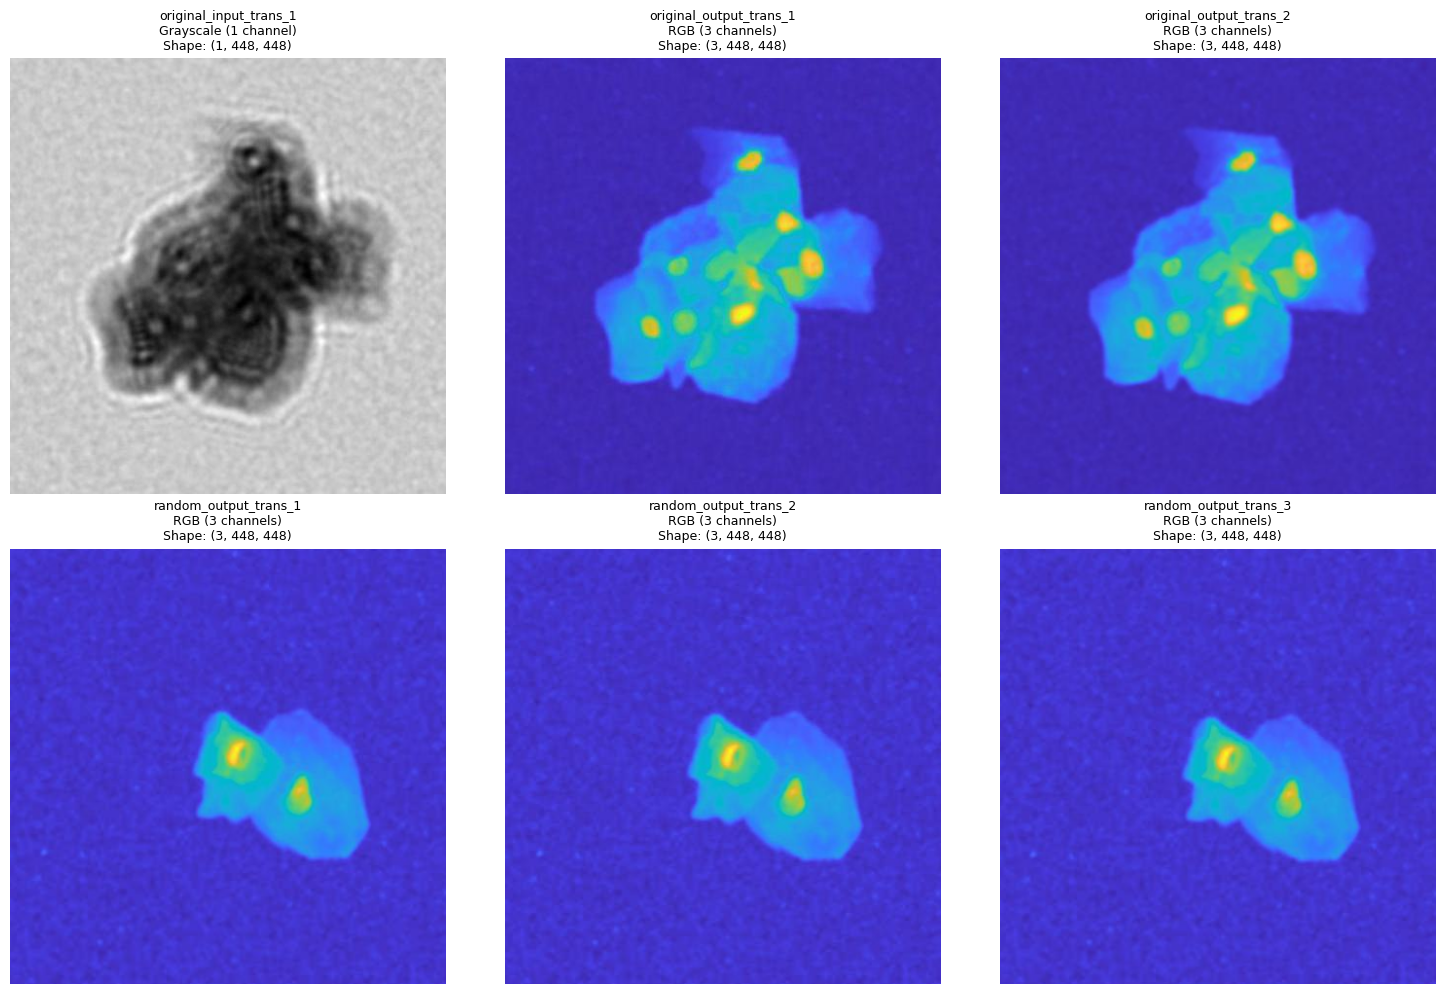


BATCH SUMMARY
Batch size: 2
Number of different image types: 6
Input (grayscale): ['original_input_trans_1']
Output (RGB): ['original_output_trans_1', 'original_output_trans_2', 'random_output_trans_1', 'random_output_trans_2', 'random_output_trans_3']


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Select which batch you want
k = 1

# Iterate over train_loader and pick kth batch
for i, batch in enumerate(train_loader, start=1):
    if i == k:
        selected_batch = batch
        break

# Print keys in selected batch
print(f"Keys in batch {k}:", selected_batch.keys())

# Print tensor details
for key, value in selected_batch.items():
    print(
        f"{key}: shape={value.shape}, dtype={value.dtype}, "
        f"min={value.min().item():.4f}, max={value.max().item():.4f}"
    )

print("\n" + "="*60)
print("VISUALIZING FIRST IMAGE FROM EACH TENSOR [0,:,:,:]")
print("="*60)

# Get all the keys
keys = list(selected_batch.keys())

# Calculate grid size for subplots
n_images = len(keys)
cols = 3
rows = (n_images + cols - 1) // cols  # Calculate rows needed

# Create figure with subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))

# Flatten axes array for easier indexing
if rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

# Plot each image
for idx, key in enumerate(keys):
    # Get the first image from the batch [0, :, :, :]
    img = selected_batch[key][0].cpu().numpy()  # Shape: (C, H, W)
    
    # Check if it's grayscale (1 channel) or RGB (3 channels)
    if img.shape[0] == 1:
        # Grayscale: shape is (1, H, W)
        img_display = img[0]  # Extract (H, W)
        axes[idx].imshow(img_display, cmap='gray', vmin=0, vmax=1)
        channel_info = "Grayscale (1 channel)"
    else:
        # RGB: shape is (3, H, W), need to convert to (H, W, 3)
        img_display = np.transpose(img, (1, 2, 0))  # Convert to (H, W, 3)
        # Clip values to [0, 1] for display
        img_display = np.clip(img_display, 0, 1)
        axes[idx].imshow(img_display)
        channel_info = "RGB (3 channels)"
    
    # Set title with key name and shape
    axes[idx].set_title(f'{key}\n{channel_info}\nShape: {img.shape}', fontsize=9)
    axes[idx].axis('off')
    
    # Print some statistics
    print(f"{key}:")
    print(f"  Original shape: {img.shape}")
    print(f"  Channel info: {channel_info}")
    print(f"  Min: {img.min():.4f}, Max: {img.max():.4f}")
    print(f"  Mean: {img.mean():.4f}, Std: {img.std():.4f}")
    print()

# Hide unused subplots
for idx in range(len(keys), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("BATCH SUMMARY")
print("="*60)
print(f"Batch size: {selected_batch[keys[0]].shape[0]}")
print(f"Number of different image types: {len(keys)}")
print(f"Input (grayscale): {[k for k in keys if 'input' in k]}")
print(f"Output (RGB): {[k for k in keys if 'output' in k]}")

# Train Initializer

In [24]:

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Initialize models
unet_model = UNet(in_channels=1, out_channels=3).to(device)
siamese_net = SiameseNetwork(input_channels=3).to(device)
discriminator_model = Discriminator(input_channels=3).to(device)

# Initialize optimizers
optimizer_unet = optim.Adam(unet_model.parameters(), lr=0.001)
optimizer_siamese = optim.Adam(siamese_net.parameters(), lr=0.001)
optimizer_discriminator = optim.Adam(discriminator_model.parameters(), lr=0.001)

scheduler_unet = CustomLRScheduler(optimizer=optimizer_unet,start_lr=0.001,end_lr=0.00001,decay_epochs=100)
scheduler_siamese = CustomLRScheduler(optimizer=optimizer_siamese,start_lr=0.001,end_lr=0.00001,decay_epochs=100)
scheduler_discriminator = CustomLRScheduler(optimizer=optimizer_discriminator,start_lr=0.001,end_lr=0.00001,decay_epochs=100)

# Initialize loss functions
criterion_siamese = nn.BCELoss()  # Siamese outputs probabilities
criterion_discriminator = nn.BCEWithLogitsLoss()  # Discriminator outputs logits
# criterion_siamese = nn.MSELoss()  # Siamese outputs probabilities
# criterion_discriminator = nn.MSELoss()  # Discriminator outputs logits
l1_loss = nn.L1Loss()
mse_loss = nn.MSELoss()

# Training history
train_history = {
    'unet_loss': [],
    'unet_dis': [],
    'unet_sia': [],
    'loss_dis': [],     
    'loss_sia': [],
    'loss_total': [],
    'L1': [],
    'MSE': [],
    'PSNR': [],
    'SSIM': []
}

val_history = { key: [] for key in train_history }

# Initialize best values very large
best_l1 = float("inf")
best_mse = float("inf")
best_psnr = float("-inf")
best_ssim = float("-inf")


best_l1_epoch = -1
best_mse_epoch = -1
best_psnr_epoch = -1
best_ssim_epoch = -1


Using device: cuda


# Train Items

In [25]:
def train_step(batch):
    """
    Single training step for all models - optimized to avoid redundant UNet forward passes
    """
    # Extract batch data
    original_input_trans_1 = batch['original_input_trans_1'].to(device)
    original_output_trans_1 = batch['original_output_trans_1'].to(device)
    original_output_trans_2 = batch['original_output_trans_2'].to(device)
    random_output_trans_1 = batch['random_output_trans_1'].to(device)
    random_output_trans_2 = batch['random_output_trans_2'].to(device)
    random_output_trans_3 = batch['random_output_trans_3'].to(device)
    
    # =============================================
    # 1. UNet Training (with gradient tracking)
    # =============================================
    optimizer_unet.zero_grad()
    
    # Single forward pass for UNet
    unet_output, att_map = unet_model(original_input_trans_1)
    
    # Reconstruction losses
    loss_unet_l1 = l1_loss(unet_output, original_output_trans_1)
    loss_unet_mse = mse_loss(unet_output, original_output_trans_1)
    
    # Adversarial loss - discriminator outputs logits
    unet_adversarial_pred = discriminator_model(unet_output)
    loss_unet_adversarial = criterion_discriminator(
        unet_adversarial_pred, 
        torch.ones_like(unet_adversarial_pred, device=device)
    )
    
    # Similarity loss - siamese outputs probabilities
    unet_siamese_similarity = siamese_net(unet_output, original_output_trans_2)
    unet_siamese_similarity_label = torch.zeros_like(unet_siamese_similarity)
    # Since siamese outputs probability of being dissimilar,
    # and we want UNet output to be similar to target, we minimize the similarity score
    loss_unet_similarity = criterion_siamese(unet_siamese_similarity, unet_siamese_similarity_label)
    
    # Combined UNet loss with weights
    loss_unet_total = 1.0 * loss_unet_adversarial + 1.0 * loss_unet_similarity
    
    loss_unet_total.backward()
    clip_grad_norm_(unet_model.parameters(), max_norm=1.0)
    optimizer_unet.step()
    
    # =============================================
    # Save UNet output for reuse (detach from computation graph)
    # =============================================
    unet_output_detached = unet_output.detach()
    
    # =============================================
    # 2. Siamese Network Training 
    # ============================================= 
    optimizer_siamese.zero_grad()
    
    # Siamese network outputs probabilities (has sigmoid)
    sim_similarity_1 = siamese_net(random_output_trans_1, random_output_trans_2)
    sim_labels_1 = torch.zeros_like(sim_similarity_1)
    
    sim_similarity_2 = siamese_net(random_output_trans_2, random_output_trans_3)
    sim_labels_2 = torch.zeros_like(sim_similarity_2)

    dissim_similarity = siamese_net(original_output_trans_2, random_output_trans_3)
    dissim_labels = torch.ones_like(dissim_similarity)

    # Use the saved detached UNet output
    unet_dissim_similarity = siamese_net(unet_output_detached, original_output_trans_2)
    unet_dissim_labels = torch.ones_like(unet_dissim_similarity)
    
    # Use BCELoss for siamese (outputs are probabilities)
    loss_siamese_sim_1 = criterion_siamese(sim_similarity_1, sim_labels_1)
    loss_siamese_sim_2 = criterion_siamese(sim_similarity_2, sim_labels_2)
    loss_siamese_dissim = criterion_siamese(dissim_similarity, dissim_labels)
    loss_siamese_unet_dissim = criterion_siamese(unet_dissim_similarity, unet_dissim_labels)
    
    loss_siamese_total = (loss_siamese_sim_1 + loss_siamese_sim_2 + 
                          loss_siamese_dissim + loss_siamese_unet_dissim) / 4.0
    
    loss_siamese_total.backward()
    clip_grad_norm_(siamese_net.parameters(), max_norm=1.0)
    optimizer_siamese.step()
    
    # =============================================
    # 3. Discriminator Training
    # =============================================
    optimizer_discriminator.zero_grad()
    
    # Discriminator outputs logits (no sigmoid)
    real_pred = discriminator_model(original_output_trans_2)
    real_labels = torch.ones_like(real_pred)
    
    # Use the saved detached UNet output
    fake_pred = discriminator_model(unet_output_detached)
    fake_labels = torch.zeros_like(fake_pred)
    
    # Use BCEWithLogitsLoss for discriminator (outputs are logits)
    loss_discriminator_real = criterion_discriminator(real_pred, real_labels)
    loss_discriminator_fake = criterion_discriminator(fake_pred, fake_labels)
    loss_discriminator_total = (loss_discriminator_real + loss_discriminator_fake) / 2.0
    
    loss_discriminator_total.backward()
    clip_grad_norm_(discriminator_model.parameters(), max_norm=1.0)
    optimizer_discriminator.step()

    # =============================================
    # PSNR & SSIM (skimage version)
    # =============================================
    with torch.no_grad():
        pred = torch.clamp(unet_output_detached, 0, 1)
        target = torch.clamp(original_output_trans_1, 0, 1)

        pred_np = pred.permute(0, 2, 3, 1).cpu().numpy()   # (B, H, W, C)
        target_np = target.permute(0, 2, 3, 1).cpu().numpy()

        psnr_list = []
        ssim_list = []

        for i in range(pred_np.shape[0]):
            p = pred_np[i]
            t = target_np[i]

            # PSNR
            psnr_val = psnr(t, p, data_range=1.0)

            # SSIM (for RGB images)
            ssim_val = ssim(t, p, data_range=1.0, channel_axis=-1)

            psnr_list.append(psnr_val)
            ssim_list.append(ssim_val)

        psnr_mean = sum(psnr_list) / len(psnr_list)
        ssim_mean = sum(ssim_list) / len(ssim_list)  
    
    # =============================================
    # Return losses for logging
    # =============================================
    return {
        'unet_loss': loss_unet_total.item(),
        'unet_dis': loss_unet_adversarial.item(),
        'unet_sia': loss_unet_similarity.item(),
        'loss_dis': loss_discriminator_total.item(),
        'loss_sia': loss_siamese_total.item(),
        'loss_total': (loss_unet_total + loss_siamese_total + loss_discriminator_total).item(),
        'L1': loss_unet_l1.item(),
        'MSE': loss_unet_mse.item(),
        'PSNR': psnr_mean,
        'SSIM': ssim_mean
    }

In [26]:
# def train_step(batch):
#     """
#     Single training step for all models - optimized to avoid redundant UNet forward passes
#     """
#     # Extract batch data
#     original_input_trans_1 = batch['original_input_trans_1'].to(device)
#     original_output_trans_1 = batch['original_output_trans_1'].to(device)
#     original_output_trans_2 = batch['original_output_trans_2'].to(device)
#     random_output_trans_1 = batch['random_output_trans_1'].to(device)
#     random_output_trans_2 = batch['random_output_trans_2'].to(device)
#     random_output_trans_3 = batch['random_output_trans_3'].to(device)
    
#     # =============================================
#     # 1. UNet Training (with gradient tracking)
#     # =============================================
#     optimizer_unet.zero_grad()
    
#     # Single forward pass for UNet
#     unet_output, att_map = unet_model(original_input_trans_1)
    
#     # Reconstruction losses
#     loss_unet_l1 = l1_loss(unet_output, original_output_trans_1)
#     loss_unet_mse = mse_loss(unet_output, original_output_trans_1)
    
#     # Adversarial loss - discriminator outputs logits
#     unet_adversarial_pred = discriminator_model(unet_output)
#     loss_unet_adversarial = criterion_discriminator(
#         unet_adversarial_pred, 
#         torch.ones_like(unet_adversarial_pred, device=device)
#     )
    
#     # Similarity loss - siamese outputs probabilities
#     unet_siamese_similarity = siamese_net(unet_output, original_output_trans_2)
#     unet_siamese_similarity_label = torch.zeros_like(unet_siamese_similarity)
#     # Since siamese outputs probability of being dissimilar,
#     # and we want UNet output to be similar to target, we minimize the similarity score
#     loss_unet_similarity = criterion_siamese(unet_siamese_similarity, unet_siamese_similarity_label)
    
#     # Combined UNet loss with weights
#     loss_unet_total = 1.0 * loss_unet_adversarial + 1.0 * loss_unet_similarity
    
#     loss_unet_total.backward()
#     clip_grad_norm_(unet_model.parameters(), max_norm=1.0)
#     optimizer_unet.step()
    
#     # =============================================
#     # Save UNet output for reuse (detach from computation graph)
#     # =============================================
#     unet_output_detached = unet_output.detach()
    
#     # =============================================
#     # 2. Siamese Network Training 
#     # ============================================= 
#     optimizer_siamese.zero_grad()
    
#     # Siamese network outputs probabilities (has sigmoid)
#     sim_similarity_1 = siamese_net(random_output_trans_1, random_output_trans_2)
#     sim_labels_1 = torch.zeros_like(sim_similarity_1)
    
#     sim_similarity_2 = siamese_net(random_output_trans_2, random_output_trans_3)
#     sim_labels_2 = torch.zeros_like(sim_similarity_2)

#     dissim_similarity = siamese_net(original_output_trans_2, random_output_trans_3)
#     dissim_labels = torch.ones_like(dissim_similarity)

#     # Use the saved detached UNet output
#     unet_dissim_similarity = siamese_net(unet_output_detached, original_output_trans_2)
#     unet_dissim_labels = torch.ones_like(unet_dissim_similarity)
    
#     # Use BCELoss for siamese (outputs are probabilities)
#     loss_siamese_sim_1 = criterion_siamese(sim_similarity_1, sim_labels_1)
#     loss_siamese_sim_2 = criterion_siamese(sim_similarity_2, sim_labels_2)
#     loss_siamese_dissim = criterion_siamese(dissim_similarity, dissim_labels)
#     loss_siamese_unet_dissim = criterion_siamese(unet_dissim_similarity, unet_dissim_labels)
    
#     loss_siamese_total = (loss_siamese_sim_1 + loss_siamese_sim_2 + 
#                           loss_siamese_dissim + loss_siamese_unet_dissim) / 4.0
    
#     loss_siamese_total.backward()
#     clip_grad_norm_(siamese_net.parameters(), max_norm=1.0)
#     optimizer_siamese.step()
    
#     # =============================================
#     # 3. Discriminator Training
#     # =============================================
#     optimizer_discriminator.zero_grad()
    
#     # Discriminator outputs logits (no sigmoid)
#     real_pred = discriminator_model(original_output_trans_2)
#     real_labels = torch.ones_like(real_pred)
    
#     # Use the saved detached UNet output
#     fake_pred = discriminator_model(unet_output_detached)
#     fake_labels = torch.zeros_like(fake_pred)
    
#     # Use BCEWithLogitsLoss for discriminator (outputs are logits)
#     loss_discriminator_real = criterion_discriminator(real_pred, real_labels)
#     loss_discriminator_fake = criterion_discriminator(fake_pred, fake_labels)
#     loss_discriminator_total = (loss_discriminator_real + loss_discriminator_fake) / 2.0
    
#     loss_discriminator_total.backward()
#     clip_grad_norm_(discriminator_model.parameters(), max_norm=1.0)
#     optimizer_discriminator.step()

#     # =============================================
#     # PSNR & SSIM (skimage version)
#     # =============================================
#     with torch.no_grad():
#         pred = torch.clamp(unet_output_detached, 0, 1)
#         target = torch.clamp(original_output_trans_1, 0, 1)

#         pred_np = pred.permute(0, 2, 3, 1).cpu().numpy()   # (B, H, W, C)
#         target_np = target.permute(0, 2, 3, 1).cpu().numpy()

#         psnr_list = []
#         ssim_list = []

#         for i in range(pred_np.shape[0]):
#             p = pred_np[i]
#             t = target_np[i]

#             # PSNR
#             psnr_val = psnr(t, p, data_range=1.0)

#             # SSIM (for RGB images)
#             ssim_val = ssim(t, p, data_range=1.0, channel_axis=-1)

#             psnr_list.append(psnr_val)
#             ssim_list.append(ssim_val)

#         psnr_mean = sum(psnr_list) / len(psnr_list)
#         ssim_mean = sum(ssim_list) / len(ssim_list)  
    
#     # =============================================
#     # Return losses for logging
#     # =============================================
#     return {
#         'unet_loss': loss_unet_total.item(),
#         'unet_dis': loss_unet_adversarial.item(),
#         'unet_sia': loss_unet_similarity.item(),
#         'loss_dis': loss_discriminator_total.item(),
#         'loss_sia': loss_siamese_total.item(),
#         'loss_total': (loss_unet_total + loss_siamese_total + loss_discriminator_total).item(),
#         'L1': loss_unet_l1.item(),
#         'MSE': loss_unet_mse.item(),
#         'PSNR': psnr_mean,
#         'SSIM': ssim_mean
#     }

In [27]:
# Train for one epoch

def train_epoch(dataloader, epoch):
    """
    Train for one epoch
    """
    unet_model.train()
    siamese_net.train()
    discriminator_model.train()
    
    epoch_losses = {
        'unet_loss': 0,
        'loss_dis': 0,
        'loss_sia': 0,
        'unet_dis': 0,
        'unet_sia': 0,
        'loss_total': 0,
        'L1': 0,
        'MSE': 0,
        'PSNR': 0,
        'SSIM': 0
    }
    
    num_batches = len(dataloader)
    
    with tqdm(dataloader, desc=f'Epoch {epoch+1}') as pbar:
        for batch_idx, batch in enumerate(pbar):
            losses = train_step(batch)
            
            # Accumulate losses
            for key in epoch_losses:
                epoch_losses[key] += losses[key]
            
            # Update progress bar
            pbar.set_postfix({
                'U': f'{losses["unet_loss"]:.6f}',
                'UD': f'{losses["unet_dis"]:.6f}',
                'US': f'{losses["unet_sia"]:.6f}',
                'D': f'{losses["loss_dis"]:.6f}',
                'S': f'{losses["loss_sia"]:.6f}',
                'T': f'{losses["loss_total"]:.6f}',
                'L1': f'{losses["L1"]:.6f}',
                'MSE': f'{losses["MSE"]:.6f}',
                'PSNR': f'{losses["PSNR"]:.2f}',
                'SSIM': f'{losses["SSIM"]:.4f}'

            })
    
    # Average losses for the epoch
    for key in epoch_losses:
        epoch_losses[key] /= num_batches
        train_history[key].append(epoch_losses[key])
    
    return epoch_losses


In [28]:
def validatin_step(batch):
    """
    Single training step for all models - optimized to avoid redundant UNet forward passes
    """
    # Extract batch data
    original_input_trans_1 = batch['original_input_trans_1'].to(device)
    original_output_trans_1 = batch['original_output_trans_1'].to(device)
    original_output_trans_2 = batch['original_output_trans_2'].to(device)
    random_output_trans_1 = batch['random_output_trans_1'].to(device)
    random_output_trans_2 = batch['random_output_trans_2'].to(device)
    random_output_trans_3 = batch['random_output_trans_3'].to(device)
    
    # =============================================
    # 1. UNet Training (with gradient tracking)
    # =============================================
    # optimizer_unet.zero_grad()
    
    # Single forward pass for UNet
    unet_output, att_map = unet_model(original_input_trans_1)
    
    # Reconstruction losses
    loss_unet_l1 = l1_loss(unet_output, original_output_trans_1)
    loss_unet_mse = mse_loss(unet_output, original_output_trans_1)
    
    # Adversarial loss - discriminator outputs logits
    unet_adversarial_pred = discriminator_model(unet_output)
    loss_unet_adversarial = criterion_discriminator(
        unet_adversarial_pred, 
        torch.ones_like(unet_adversarial_pred, device=device)
    )
    
    # Similarity loss - siamese outputs probabilities
    unet_siamese_similarity = siamese_net(unet_output, original_output_trans_2)
    unet_siamese_similarity_label = torch.zeros_like(unet_siamese_similarity)
    # Since siamese outputs probability of being dissimilar,
    # and we want UNet output to be similar to target, we minimize the similarity score
    loss_unet_similarity = criterion_siamese(unet_siamese_similarity, unet_siamese_similarity_label)
    
    # Combined UNet loss with weights
    loss_unet_total = 1.0 * loss_unet_adversarial + 1.0 * loss_unet_similarity
    
    # loss_unet_total.backward()
    # clip_grad_norm_(unet_model.parameters(), max_norm=1.0)
    # optimizer_unet.step()
    
    # =============================================
    # Save UNet output for reuse (detach from computation graph)
    # =============================================
    unet_output_detached = unet_output.detach()
    
    # =============================================
    # 2. Siamese Network Training 
    # ============================================= 
    # optimizer_siamese.zero_grad()
    
    # Siamese network outputs probabilities (has sigmoid)
    sim_similarity_1 = siamese_net(random_output_trans_1, random_output_trans_2)
    sim_labels_1 = torch.zeros_like(sim_similarity_1)
    
    sim_similarity_2 = siamese_net(random_output_trans_2, random_output_trans_3)
    sim_labels_2 = torch.zeros_like(sim_similarity_2)

    dissim_similarity = siamese_net(original_output_trans_2, random_output_trans_3)
    dissim_labels = torch.ones_like(dissim_similarity)

    # Use the saved detached UNet output
    unet_dissim_similarity = siamese_net(unet_output_detached, original_output_trans_2)
    unet_dissim_labels = torch.ones_like(unet_dissim_similarity)
    
    # Use BCELoss for siamese (outputs are probabilities)
    loss_siamese_sim_1 = criterion_siamese(sim_similarity_1, sim_labels_1)
    loss_siamese_sim_2 = criterion_siamese(sim_similarity_2, sim_labels_2)
    loss_siamese_dissim = criterion_siamese(dissim_similarity, dissim_labels)
    loss_siamese_unet_dissim = criterion_siamese(unet_dissim_similarity, unet_dissim_labels)
    
    loss_siamese_total = (loss_siamese_sim_1 + loss_siamese_sim_2 + 
                          loss_siamese_dissim + loss_siamese_unet_dissim) / 4.0
    
    # loss_siamese_total.backward()
    # clip_grad_norm_(siamese_net.parameters(), max_norm=1.0)
    # optimizer_siamese.step()
    
    # =============================================
    # 3. Discriminator Training
    # =============================================
    # optimizer_discriminator.zero_grad()
    
    # Discriminator outputs logits (no sigmoid)
    real_pred = discriminator_model(original_output_trans_2)
    real_labels = torch.ones_like(real_pred)
    
    # Use the saved detached UNet output
    fake_pred = discriminator_model(unet_output_detached)
    fake_labels = torch.zeros_like(fake_pred)
    
    # Use BCEWithLogitsLoss for discriminator (outputs are logits)
    loss_discriminator_real = criterion_discriminator(real_pred, real_labels)
    loss_discriminator_fake = criterion_discriminator(fake_pred, fake_labels)
    loss_discriminator_total = (loss_discriminator_real + loss_discriminator_fake) / 2.0
    
    # loss_discriminator_total.backward()
    # clip_grad_norm_(discriminator_model.parameters(), max_norm=1.0)
    # optimizer_discriminator.step()
    
    # =============================================
    # PSNR & SSIM (skimage version)
    # =============================================
    with torch.no_grad():
        pred = torch.clamp(unet_output_detached, 0, 1)
        target = torch.clamp(original_output_trans_1, 0, 1)

        pred_np = pred.permute(0, 2, 3, 1).cpu().numpy()   # (B, H, W, C)
        target_np = target.permute(0, 2, 3, 1).cpu().numpy()

        psnr_list = []
        ssim_list = []

        for i in range(pred_np.shape[0]):
            p = pred_np[i]
            t = target_np[i]

            # PSNR
            psnr_val = psnr(t, p, data_range=1.0)

            # SSIM (for RGB images)
            ssim_val = ssim(t, p, data_range=1.0, channel_axis=-1)

            psnr_list.append(psnr_val)
            ssim_list.append(ssim_val)

        psnr_mean = sum(psnr_list) / len(psnr_list)
        ssim_mean = sum(ssim_list) / len(ssim_list)  

    # =============================================
    # Return losses for logging
    # =============================================
    return {
        'unet_loss': loss_unet_total.item(),
        'unet_dis': loss_unet_adversarial.item(),
        'unet_sia': loss_unet_similarity.item(),
        'loss_dis': loss_discriminator_total.item(),
        'loss_sia': loss_siamese_total.item(),
        'loss_total': (loss_unet_total + loss_siamese_total + loss_discriminator_total).item(),
        'L1': loss_unet_l1.item(),
        'MSE': loss_unet_mse.item(),
        'PSNR': psnr_mean,
        'SSIM': ssim_mean

    }

In [29]:
@torch.no_grad()
def val_epoch(val_dataloader, epoch):
    """
    Validation step
    """
    unet_model.eval()
    siamese_net.eval()
    discriminator_model.eval()
    
    val_losses = {
        'unet_loss': 0,
        'loss_dis': 0,
        'loss_sia': 0,
        'unet_dis': 0,
        'unet_sia': 0,
        'loss_total': 0,
        'L1': 0,
        'MSE': 0,
        'PSNR': 0,
        'SSIM': 0
    }
    
    num_batches = len(val_dataloader)

    # have tqdm for validation as well like training

    with tqdm(val_dataloader, desc=f'Epoch {epoch+1}') as pbar:
        for batch_idx, batch in enumerate(pbar):
            losses = validatin_step(batch)
            
            # Accumulate losses
            for key in val_losses:
                val_losses[key] += losses[key]
            
            # Update progress bar
            pbar.set_postfix({
                'U': f'{losses["unet_loss"]:.6f}',
                'UD': f'{losses["unet_dis"]:.6f}',
                'US': f'{losses["unet_sia"]:.6f}',
                'D': f'{losses["loss_dis"]:.6f}',
                'S': f'{losses["loss_sia"]:.6f}',
                'T': f'{losses["loss_total"]:.6f}',
                'L1': f'{losses["L1"]:.6f}',
                'MSE': f'{losses["MSE"]:.6f}',
                'PSNR': f'{losses["PSNR"]:.2f}',
                'SSIM': f'{losses["SSIM"]:.4f}'

            })

    # Average validation losses
    for key in val_losses:
        val_losses[key] /= num_batches
        val_history[key].append(val_losses[key])
    
    return val_losses

In [30]:
# Save Validation Images 

def save_validation_samples(val_dataloader, epoch, save_dir='validation_samples'):
    """
    Save validation samples:
    - One .npy file with input, UNet output, and ground truth
    - One comparison image with all samples as subplots
    """
    unet_model.eval()
    
    # Create directories
    image_dir = os.path.join(save_dir, 'images')
    numpy_dir = os.path.join(save_dir, 'numpy')
    os.makedirs(image_dir, exist_ok=True)
    os.makedirs(numpy_dir, exist_ok=True)
    
    with torch.no_grad():
        # Get first batch
        batch = next(iter(val_dataloader))
        
        # Extract data
        input_tensor = batch['original_input_trans_1'].to(device)  # Grayscale (B, 1, H, W)
        gt_tensor = batch['original_output_trans_1'].to(device)     # RGB (B, 3, H, W)
        
        # Forward pass
        output_tensor, att_map = unet_model(input_tensor)  # RGB output (B, 3, H, W)
        
        # Convert to numpy
        input_np = input_tensor.cpu().numpy()
        output_np = output_tensor.cpu().numpy()
        gt_np = gt_tensor.cpu().numpy()
        
        # Save numpy file (uncompressed)
        numpy_path = os.path.join(numpy_dir, f'epoch_{epoch+1}_validation_data.npy')
        np.save(numpy_path, {
            "input": input_np,
            "unet_output": output_np,
            "ground_truth": gt_np
        })
        # print(f"Saved numpy data: {numpy_path}")
        
        # Plot all samples in one figure
        batch_size = input_np.shape[0]
        fig, axes = plt.subplots(batch_size, 3, figsize=(12, 4 * batch_size))
        
        if batch_size == 1:  # make sure axes is 2D
            axes = np.expand_dims(axes, 0)
        
        # Normalize to [0, 1] range if needed
        def normalize(img):
            img_min, img_max = img.min(), img.max()
            if img_max > img_min:
                return (img - img_min) / (img_max - img_min)
            else:
                return img
        
        for i in range(batch_size):
            inp = input_np[i]   # Shape: (1, H, W) - grayscale
            out = output_np[i]  # Shape: (3, H, W) - RGB
            gt  = gt_np[i]      # Shape: (3, H, W) - RGB
            
            # Process input (grayscale)
            if inp.shape[0] == 1:  # (1, H, W) -> (H, W)
                inp_display = inp[0]
                inp_cmap = 'gray'
            else:
                inp_display = np.transpose(inp, (1, 2, 0))
                inp_cmap = None
            
            # Process UNet output (RGB)
            if out.shape[0] == 3:  # (3, H, W) -> (H, W, 3)
                out_display = np.transpose(out, (1, 2, 0))
                out_cmap = None
            elif out.shape[0] == 1:  # In case output is grayscale
                out_display = out[0]
                out_cmap = 'gray'
            else:
                out_display = np.transpose(out, (1, 2, 0))
                out_cmap = None
            
            # Process ground truth (RGB)
            if gt.shape[0] == 3:  # (3, H, W) -> (H, W, 3)
                gt_display = np.transpose(gt, (1, 2, 0))
                gt_cmap = None
            elif gt.shape[0] == 1:  # In case GT is grayscale
                gt_display = gt[0]
                gt_cmap = 'gray'
            else:
                gt_display = np.transpose(gt, (1, 2, 0))
                gt_cmap = None
            
            # Normalize each image
            inp_display = normalize(inp_display)
            out_display = normalize(out_display)
            gt_display = normalize(gt_display)
            
            # Clip RGB images to [0, 1]
            if out_cmap is None:
                out_display = np.clip(out_display, 0, 1)
            if gt_cmap is None:
                gt_display = np.clip(gt_display, 0, 1)
            
            # Plot input (grayscale)
            axes[i, 0].imshow(inp_display, cmap=inp_cmap, vmin=0, vmax=1)
            axes[i, 0].set_title(f'Input (Grayscale)\nShape: {inp.shape}')
            axes[i, 0].axis('off')
            
            # Plot UNet output (RGB)
            axes[i, 1].imshow(out_display, cmap=out_cmap)
            axes[i, 1].set_title(f'UNet Output (RGB)\nShape: {out.shape}')
            axes[i, 1].axis('off')
            
            # Plot ground truth (RGB)
            axes[i, 2].imshow(gt_display, cmap=gt_cmap)
            axes[i, 2].set_title(f'Ground Truth (RGB)\nShape: {gt.shape}')
            axes[i, 2].axis('off')
        
        plt.tight_layout()
        comp_path = os.path.join(image_dir, f'epoch_{epoch+1}_comparison.png')
        plt.savefig(comp_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        # print(f"Saved comparison image: {comp_path}")
    
    # print(f"Validation samples saved for epoch {epoch+1}")

In [31]:
# plot training and validation losses

def plot_losses(save_dir):
    """
    Plot training and validation losses and save as PNGs.
    One combined plot + one per key.
    """
    os.makedirs(save_dir, exist_ok=True)

    
    
    # --- Combined plot ---
    plt.figure(figsize=(12, 8))
    for key in train_history.keys():
        plt.plot(train_history[key], label=f"Train {key}")
        if len(val_history[key]) > 0:
            plt.plot(val_history[key], label=f"Val {key}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Losses (All)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "all_losses.png"), dpi=150, bbox_inches="tight")
    plt.close()

    # --- Individual plots ---
    for key in train_history.keys():
        plt.figure(figsize=(8, 6))
        plt.plot(train_history[key], label=f"Train {key}")
        if len(val_history[key]) > 0:
            plt.plot(val_history[key], label=f"Val {key}")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title(f"Training and Validation Loss: {key}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f"{key}_loss.png"), dpi=150, bbox_inches="tight")
        plt.close()
    
    # print(f"Loss plots saved in {save_dir}")


In [32]:
# save weights function

def save_weights(epoch,num_epochs,save_dir='model_weights'):
    """
    Save last epoch weights and best validation weights.
    """
    global best_l1, best_mse,best_psnr,best_ssim, best_l1_epoch, best_mse_epoch, best_psnr_epoch, best_ssim_epoch
    os.makedirs(save_dir, exist_ok=True)

    # print(f"Saving weights at epoch {epoch+1}...")

    # --- Save best validation weights (based on L1_loss) ---
    current_val_L1 = val_history['L1'][-1]  # last validation loss
    if current_val_L1 < best_l1:
        best_l1 = current_val_L1
        best_l1_epoch = epoch +1 
        torch.save({
            'epoch': epoch+1,
            'unet': unet_model.state_dict(),
            'siamese': siamese_net.state_dict(),
            'discriminator': discriminator_model.state_dict(),
            'history_val': val_history,
            'history_train': train_history
        }, os.path.join(save_dir, "best_l1_epoch.pth"))
        print(f"✅ Best L1 Loss model updated at epoch {epoch+1} with val_loss={current_val_L1:.4f}")
        
    # --- Save best validation weights (based on MSE_loss) ---
    current_val_MSE = val_history['MSE'][-1]  # last validation loss
    current_val_PSNR = val_history['PSNR'][-1]  # last validation PSNR
    current_val_SSIM = val_history['SSIM'][-1]  # last validation
    if current_val_MSE < best_mse:
        best_mse = current_val_MSE
        best_psnr = current_val_PSNR
        best_ssim = current_val_SSIM
        best_mse_epoch = epoch + 1
        best_psnr_epoch = epoch + 1
        best_ssim_epoch = epoch + 1
        torch.save({
            'epoch': epoch+1,
            'unet': unet_model.state_dict(),
            'siamese': siamese_net.state_dict(),
            'discriminator': discriminator_model.state_dict(),
            'history_val': val_history,
            'history_train': train_history
        }, os.path.join(save_dir, "best_mse_epoch.pth"))
        print(f"✅ Best MSE Loss model updated at epoch {epoch+1} with val_loss={current_val_MSE:.4f}")
        
    # --- Save last epoch weights ---
    if (epoch + 1) == num_epochs:
        torch.save({
            'epoch': epoch+1,
            'unet': unet_model.state_dict(),
            'siamese': siamese_net.state_dict(),
            'discriminator': discriminator_model.state_dict(),
            'history_val': val_history,
            'history_train': train_history
        }, os.path.join(save_dir, "last_epoch.pth"))
        print(f"✅ Last epoch model saved at epoch {epoch+1}")
        
    
    # print(f"Weights saved in {save_dir}")    
    

# Train It

In [ ]:
import time

# Training parameters
num_epochs = 100
validate_every = 1
save_samples_every = 1
save_dir = "../weaksup_Results/ww01_LIDHM_12april_004_13april"

print("Starting training...")
print(f"Total epochs: {num_epochs}")

# ⏱️ Start total timer
training_start_time = time.time()

def format_time(seconds):
    hrs = int(seconds // 3600)
    mins = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    return f"{hrs:02d}:{mins:02d}:{secs:02d}"

for epoch in range(num_epochs):
    
    # ⏱️ Start epoch timer
    epoch_start_time = time.time()
    
    # ============================
    # Training
    # ============================
    train_losses = train_epoch(train_loader, epoch)
    print(
        f"unet_loss : {train_losses['unet_loss']:.6f} | "
        f"unet_dis : {train_losses['unet_dis']:.6f} | "
        f"unet_sia : {train_losses['unet_sia']:.6f} | "
        f"loss_dis : {train_losses['loss_dis']:.6f} | "
        f"loss_sia : {train_losses['loss_sia']:.6f} | "
        f"loss_total : {train_losses['loss_total']:.6f} | "
        f"L1: {train_losses['L1']:.6f} | "
        f"MSE: {train_losses['MSE']:.6f} | "
        f"PSNR: {train_losses['PSNR']:.6f} | "
        f"SSIM: {train_losses['SSIM']:.6f}"
    )

    # ============================
    # Validation
    # ============================
    val_losses = val_epoch(val_loader, epoch)
    print(
        f"unet_loss : {val_losses['unet_loss']:.6f} | "
        f"unet_dis : {val_losses['unet_dis']:.6f} | "
        f"unet_sia : {val_losses['unet_sia']:.6f} | "
        f"loss_dis : {val_losses['loss_dis']:.6f} | "
        f"loss_sia : {val_losses['loss_sia']:.6f} | "
        f"loss_total : {val_losses['loss_total']:.6f} | "
        f"L1: {val_losses['L1']:.6f} | "
        f"MSE: {val_losses['MSE']:.6f} | "
        f"PSNR: {val_losses['PSNR']:.6f} | "
        f"SSIM: {val_losses['SSIM']:.6f}"
    )
    
    print("Saving Validation Samples and Plotting losses...")

    if (epoch + 1) % save_samples_every == 0:
        save_validation_samples(val_loader, epoch, save_dir=save_dir)
        
    plot_losses(save_dir=save_dir)
    save_weights(epoch, num_epochs, save_dir=save_dir)
    
    print(f"best_l1: {best_l1:.4f} at epoch {best_l1_epoch} | best_mse: {best_mse:.4f} at epoch {best_mse_epoch} | best_psnr: {best_psnr:.4f} | best_ssim: {best_ssim:.4f} ")

    scheduler_unet.step()
    scheduler_siamese.step()
    scheduler_discriminator.step()

    lr_unet = optimizer_unet.param_groups[0]['lr']
    lr_siamese = optimizer_siamese.param_groups[0]['lr']
    lr_discriminator = optimizer_discriminator.param_groups[0]['lr']
    
    print(f"Learning Rates - UNet: {lr_unet:.6f}, Siamese: {lr_siamese:.6f}, Discriminator: {lr_discriminator:.6f}")

    # ============================
    # ⏱️ Time Calculation
    # ============================
    epoch_time = time.time() - epoch_start_time
    total_elapsed_time = time.time() - training_start_time

    avg_epoch_time = total_elapsed_time / (epoch + 1)
    remaining_epochs = num_epochs - (epoch + 1)
    estimated_remaining_time = avg_epoch_time * remaining_epochs

    print(f"Epoch Time: {format_time(epoch_time)} | Total Elapsed Time: {format_time(total_elapsed_time)} | Estimated Remaining Time: {format_time(estimated_remaining_time)}")

    print("-" * 150)

print("Training completed!")

Starting training...
Total epochs: 100


Epoch 1: 100%|██████████| 241/241 [01:55<00:00,  2.08it/s, U=15.275756, UD=11.575310, US=3.700446, D=0.000348, S=2.891067, T=18.167170, L1=0.123353, MSE=0.033892, PSNR=14.73, SSIM=0.1250]    


unet_loss : 36.691819 | unet_dis : 5.245108 | unet_sia : 31.446712 | loss_dis : 0.289668 | loss_sia : 0.898259 | loss_total : 37.879746 | L1: 0.233168 | MSE: 0.076263 | PSNR: 11.282709 | SSIM: 0.174434


Epoch 1: 100%|██████████| 41/41 [00:13<00:00,  2.97it/s, U=118.614822, UD=18.614824, US=100.000000, D=11.566330, S=0.828564, T=131.009720, L1=0.206670, MSE=0.087398, PSNR=10.58, SSIM=0.1112]


unet_loss : 44.399265 | unet_dis : 22.756438 | unet_sia : 21.642827 | loss_dis : 11.719183 | loss_sia : 0.518331 | loss_total : 56.636779 | L1: 0.202804 | MSE: 0.083765 | PSNR: 10.779893 | SSIM: 0.118985
Saving Validation Samples and Plotting losses...
✅ Best L1 Loss model updated at epoch 1 with val_loss=0.2028
✅ Best MSE Loss model updated at epoch 1 with val_loss=0.0838
best_l1: 0.2028 at epoch 1 | best_mse: 0.0838 at epoch 1 | best_psnr: 10.7799 | best_ssim: 0.1190 
Learning Rates - UNet: 0.000990, Siamese: 0.000990, Discriminator: 0.000990
Epoch Time: 00:02:15 | Total Elapsed Time: 00:02:15 | Estimated Remaining Time: 03:43:33
------------------------------------------------------------------------------------------------------------------------------------------------------


...

unet_loss : 108.047413 | unet_dis : 8.047413 | unet_sia : 100.000000 | loss_dis : 0.529325 | loss_sia : 6.918793 | loss_total : 115.495530 | L1: 0.112436 | MSE: 0.024056 | PSNR: 16.470671 | SSIM: 0.681850
Saving Validation Samples and Plotting losses...
best_l1: 0.0563 at epoch 24 | best_mse: 0.0111 at epoch 34 | best_psnr: 19.9035 | best_ssim: 0.6471 
Learning Rates - UNet: 0.000654, Siamese: 0.000654, Discriminator: 0.000654
Epoch Time: 00:02:11 | Total Elapsed Time: 01:18:30 | Estimated Remaining Time: 02:25:48
------------------------------------------------------------------------------------------------------------------------------------------------------


Epoch 36: 100%|██████████| 241/241 [01:54<00:00,  2.10it/s, U=58.885269, UD=8.885270, US=50.000000, D=0.000802, S=2.646409, T=61.532478, L1=0.102505, MSE=0.028254, PSNR=16.28, SSIM=0.6853]     


unet_loss : 72.529110 | unet_dis : 7.654087 | unet_sia : 64.875022 | loss_dis : 0.136397 | loss_sia : 3.950990 | loss_total : 76.616496 | L1: 0.114287 | MSE: 0.035115 | PSNR: 15.550576 | SSIM: 0.567698


Epoch 36: 100%|██████████| 41/41 [00:13<00:00,  3.08it/s, U=24.054411, UD=8.112026, US=15.942385, D=0.015654, S=6.601033, T=30.671099, L1=0.175917, MSE=0.058374, PSNR=12.34, SSIM=0.4781]     


unet_loss : 88.691870 | unet_dis : 10.061933 | unet_sia : 78.629937 | loss_dis : 0.076846 | loss_sia : 8.448548 | loss_total : 97.217263 | L1: 0.088640 | MSE: 0.022072 | PSNR: 17.562564 | SSIM: 0.704407
Saving Validation Samples and Plotting losses...


# Eval

In [ ]:
# save_dir = "../weaksup_Results/vw06_LIDHM_04april_noDes_001_04april"

In [ ]:
# import torch
# import numpy as np
# from skimage.metrics import structural_similarity as ssim
# from skimage.metrics import peak_signal_noise_ratio as psnr
# from tqdm import tqdm

def evaluate_model(checkpoint_path, train_loader, val_loader, device='cuda'):
    """
    Evaluate model on train and validation sets with all metrics.
    
    Args:
        checkpoint_path: Path to the .pth file
        train_loader: Training dataloader
        val_loader: Validation dataloader
        device: Device to run evaluation on
    
    Returns:
        Dictionary containing all metrics for both train and val sets
    """
    
    # Load checkpoint
    print(f"Loading checkpoint from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device,weights_only=False)
    
    # Load model states
    unet_model.load_state_dict(checkpoint['unet'])
    siamese_net.load_state_dict(checkpoint['siamese'])
    discriminator_model.load_state_dict(checkpoint['discriminator'])
    
    # Set models to eval mode
    unet_model.eval()
    siamese_net.eval()
    discriminator_model.eval()
    
    print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
    
    # Define metric computation function
    def compute_metrics(loader, dataset_name='Train'):
        metrics = {
            'unet_loss': [], 'unet_adversarial': [], 'unet_similarity': [],
            'discriminator_loss': [], 'siamese_loss': [], 'total_loss': [],
            'L1': [], 'MSE': [], 'PSNR': [], 'SSIM': []
        }
        
        with torch.no_grad():
            for batch in tqdm(loader, desc=f"Evaluating {dataset_name}"):
                # Extract batch data
                original_input_trans_1 = batch['original_input_trans_1'].to(device)
                original_output_trans_1 = batch['original_output_trans_1'].to(device)
                original_output_trans_2 = batch['original_output_trans_2'].to(device)
                random_output_trans_1 = batch['random_output_trans_1'].to(device)
                random_output_trans_2 = batch['random_output_trans_2'].to(device)
                random_output_trans_3 = batch['random_output_trans_3'].to(device)
                
                # =============================================
                # UNet Forward Pass
                # =============================================
                unet_output, att_map = unet_model(original_input_trans_1)
                
                # Reconstruction losses
                loss_unet_l1 = l1_loss(unet_output, original_output_trans_1)
                loss_unet_mse = mse_loss(unet_output, original_output_trans_1)
                
                # Adversarial loss
                unet_adversarial_pred = discriminator_model(unet_output)
                loss_unet_adversarial = criterion_discriminator(
                    unet_adversarial_pred, 
                    torch.ones_like(unet_adversarial_pred, device=device)
                )
                
                # Similarity loss
                unet_siamese_similarity = siamese_net(unet_output, original_output_trans_2)
                unet_siamese_similarity_label = torch.zeros_like(unet_siamese_similarity)
                loss_unet_similarity = criterion_siamese(unet_siamese_similarity, unet_siamese_similarity_label)
                
                # Combined UNet loss
                loss_unet_total = 1.0 * loss_unet_adversarial + 1.0 * loss_unet_similarity
                
                # =============================================
                # Siamese Network Losses
                # =============================================
                sim_similarity_1 = siamese_net(random_output_trans_1, random_output_trans_2)
                sim_labels_1 = torch.zeros_like(sim_similarity_1)
                
                sim_similarity_2 = siamese_net(random_output_trans_2, random_output_trans_3)
                sim_labels_2 = torch.zeros_like(sim_similarity_2)
                
                dissim_similarity = siamese_net(original_output_trans_2, random_output_trans_3)
                dissim_labels = torch.ones_like(dissim_similarity)
                
                unet_dissim_similarity = siamese_net(unet_output, original_output_trans_2)
                unet_dissim_labels = torch.ones_like(unet_dissim_similarity)
                
                loss_siamese_sim_1 = criterion_siamese(sim_similarity_1, sim_labels_1)
                loss_siamese_sim_2 = criterion_siamese(sim_similarity_2, sim_labels_2)
                loss_siamese_dissim = criterion_siamese(dissim_similarity, dissim_labels)
                loss_siamese_unet_dissim = criterion_siamese(unet_dissim_similarity, unet_dissim_labels)
                
                loss_siamese_total = (loss_siamese_sim_1 + loss_siamese_sim_2 + 
                                      loss_siamese_dissim + loss_siamese_unet_dissim) / 4.0
                
                # =============================================
                # Discriminator Losses
                # =============================================
                real_pred = discriminator_model(original_output_trans_2)
                real_labels = torch.ones_like(real_pred)
                
                fake_pred = discriminator_model(unet_output)
                fake_labels = torch.zeros_like(fake_pred)
                
                loss_discriminator_real = criterion_discriminator(real_pred, real_labels)
                loss_discriminator_fake = criterion_discriminator(fake_pred, fake_labels)
                loss_discriminator_total = (loss_discriminator_real + loss_discriminator_fake) / 2.0
                
                # =============================================
                # PSNR and SSIM Calculation
                # =============================================
                # Convert to numpy for PSNR and SSIM calculation
                unet_output_np = unet_output.cpu().numpy()
                target_np = original_output_trans_1.cpu().numpy()
                
                batch_psnr = []
                batch_ssim = []
                
                for i in range(unet_output_np.shape[0]):
                    # Assuming images are in range [0, 1] or normalize them
                    img_pred = unet_output_np[i].transpose(1, 2, 0)  # C,H,W -> H,W,C
                    img_true = target_np[i].transpose(1, 2, 0)
                    
                    # Clip values to [0, 1] range if needed
                    img_pred = np.clip(img_pred, 0, 1)
                    img_true = np.clip(img_true, 0, 1)
                    
                    # Calculate PSNR
                    psnr_val = psnr(img_true, img_pred, data_range=1.0)
                    batch_psnr.append(psnr_val)
                    
                    # Calculate SSIM
                    if img_pred.shape[2] == 1:  # Grayscale
                        ssim_val = ssim(img_true.squeeze(), img_pred.squeeze(), data_range=1.0)
                    else:  # RGB
                        ssim_val = ssim(img_true, img_pred, data_range=1.0, channel_axis=2)
                    batch_ssim.append(ssim_val)
                
                # Store metrics
                metrics['unet_loss'].append(loss_unet_total.item())
                metrics['unet_adversarial'].append(loss_unet_adversarial.item())
                metrics['unet_similarity'].append(loss_unet_similarity.item())
                metrics['discriminator_loss'].append(loss_discriminator_total.item())
                metrics['siamese_loss'].append(loss_siamese_total.item())
                metrics['total_loss'].append((loss_unet_total + loss_siamese_total + loss_discriminator_total).item())
                metrics['L1'].append(loss_unet_l1.item())
                metrics['MSE'].append(loss_unet_mse.item())
                metrics['PSNR'].extend(batch_psnr)
                metrics['SSIM'].extend(batch_ssim)
        
        # Calculate mean for all metrics
        results = {k: np.mean(v) for k, v in metrics.items()}
        results['std_PSNR'] = np.std(metrics['PSNR'])
        results['std_SSIM'] = np.std(metrics['SSIM'])
        
        return results
    
    # Evaluate on both datasets
    print("\n" + "="*60)
    print("Starting Evaluation...")
    print("="*60)
    
    train_results = compute_metrics(train_loader, 'Train')
    val_results = compute_metrics(val_loader, 'Validation')
    
    # Print results
    print("\n" + "="*60)
    print("EVALUATION RESULTS")
    print("="*60)
    
    print("\n📊 TRAIN SET METRICS:")
    print("-" * 60)
    print(f"  UNet Loss:           {train_results['unet_loss']:.6f}")
    print(f"  UNet Adversarial:    {train_results['unet_adversarial']:.6f}")
    print(f"  UNet Similarity:     {train_results['unet_similarity']:.6f}")
    print(f"  Discriminator Loss:  {train_results['discriminator_loss']:.6f}")
    print(f"  Siamese Loss:        {train_results['siamese_loss']:.6f}")
    print(f"  Total Loss:          {train_results['total_loss']:.6f}")
    print(f"  L1 Loss:             {train_results['L1']:.6f}")
    print(f"  MSE Loss:            {train_results['MSE']:.6f}")
    print(f"  PSNR:                {train_results['PSNR']:.4f} ± {train_results['std_PSNR']:.4f} dB")
    print(f"  SSIM:                {train_results['SSIM']:.6f} ± {train_results['std_SSIM']:.6f}")
    
    print("\n📊 VALIDATION SET METRICS:")
    print("-" * 60)
    print(f"  UNet Loss:           {val_results['unet_loss']:.6f}")
    print(f"  UNet Adversarial:    {val_results['unet_adversarial']:.6f}")
    print(f"  UNet Similarity:     {val_results['unet_similarity']:.6f}")
    print(f"  Discriminator Loss:  {val_results['discriminator_loss']:.6f}")
    print(f"  Siamese Loss:        {val_results['siamese_loss']:.6f}")
    print(f"  Total Loss:          {val_results['total_loss']:.6f}")
    print(f"  L1 Loss:             {val_results['L1']:.6f}")
    print(f"  MSE Loss:            {val_results['MSE']:.6f}")
    print(f"  PSNR:                {val_results['PSNR']:.4f} ± {val_results['std_PSNR']:.4f} dB")
    print(f"  SSIM:                {val_results['SSIM']:.6f} ± {val_results['std_SSIM']:.6f}")
    
    print("\n" + "="*60)
    
    return {
        'train': train_results,
        'val': val_results,
        'checkpoint_epoch': checkpoint['epoch']
    }

class Tee:
    def __init__(self, *streams):
        self.streams = streams

    def write(self, data):
        for s in self.streams:
            s.write(data)

    def flush(self):
        for s in self.streams:
            s.flush()

def save_output_as_png(text, path):
    plt.figure(figsize=(12, 10))
    plt.text(0.01, 0.99, text, va='top', ha='left', family='monospace')
    plt.axis('off')
    plt.savefig(path, bbox_inches='tight', dpi=300)
    plt.close()


buffer = StringIO()
original_stdout = sys.stdout

# 👇 This prints to notebook AND saves to buffer
sys.stdout = Tee(original_stdout, buffer)

# Run normally (you WILL see output)
results_mse = evaluate_model(
    checkpoint_path=os.path.join(save_dir, "best_mse_epoch.pth"),
    train_loader=train_loader,
    val_loader=val_loader,
    device=device
)

# Restore stdout
sys.stdout = original_stdout

# Save snapshot
output_text = buffer.getvalue()
save_output_as_png(output_text, os.path.join(save_dir, "eval_snapshot.png"))

# Get the images to plot

In [ ]:

checkpoint_path= os.path.join(save_dir, "best_mse_epoch.pth")
# checkpoint_path = r"C:\Users\vsb27\Documents\WS_I2I\weaksup_Results\vw05_LIDHM_NoDescription_001_29jan\last_epoch.pth" 

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint file not found: {checkpoint_path}")


# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Initialize models
unet_model = UNet(in_channels=1, out_channels=3).to(device)
# load the weithts from checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device,weights_only=False)
unet_model.load_state_dict(checkpoint['unet'])

In [ ]:
# make the dataloader of batch size as 1


dataset = WeaklySupervisedDataset(data_in_dir = data_in, data_out_dir = data_out, data_out_similar_dir = data_pack, resize_size=512)
# Parameters
batch_size_train = 1
# Create dataloaders
train_loader = DataLoader(dataset, batch_size=batch_size_train, shuffle=False)
print(f"Number of training batches: {len(train_loader)}")


# also give the psnr, ssim , mae and mse of the output with respect to ground truth

import torch.nn.functional as F 
def calculate_metrics(output, target):
    """
    Calculate PSNR, SSIM, MAE, and MSE between output and target tensors.
    
    Args:
        output: Output tensor from the model (B, C, H, W)
        target: Ground truth tensor (B, C, H, W) 
    Returns:
        Dictionary containing PSNR, SSIM, MAE, and MSE values.      
    """
    output_np = output.cpu().numpy()
    target_np = target.cpu().numpy()
    
    batch_psnr = []
    batch_ssim = []
    batch_mae = []
    batch_mse = []
    
    for i in range(output_np.shape[0]):
        img_pred = output_np[i].transpose(1, 2, 0)  # C,H,W -> H,W,C
        img_true = target_np[i].transpose(1, 2, 0)
        
        # Clip values to [0, 1] range if needed
        img_pred = np.clip(img_pred, 0, 1)
        img_true = np.clip(img_true, 0, 1)
        
        # Calculate PSNR
        psnr_val = psnr(img_true, img_pred, data_range=1.0)
        batch_psnr.append(psnr_val)
        
        # Calculate SSIM
        if img_pred.shape[2] == 1:  # Grayscale
            ssim_val = ssim(img_true.squeeze(), img_pred.squeeze(), data_range=1.0)
        else:  # RGB
            ssim_val = ssim(img_true, img_pred, data_range=1.0, channel_axis=2)
        batch_ssim.append(ssim_val)
        
        # Calculate MAE
        mae_val = np.mean(np.abs(img_true - img_pred))
        batch_mae.append(mae_val)
        
        # Calculate MSE
        mse_val = np.mean((img_true - img_pred) ** 2)
        batch_mse.append(mse_val)
    
    return {
        'PSNR': np.mean(batch_psnr),
        'SSIM': np.mean(batch_ssim),
        'MAE': np.mean(batch_mae),
        'MSE': np.mean(batch_mse)
    }




In [ ]:
import scipy.io as sio

# Get the k-th batch from train_loader
k = 2


for batch_idx, batch in enumerate(train_loader):
    if batch_idx == k:
        input_tensor = batch['original_input_trans_1'].to(device)  # Grayscale (B, 1, H, W)
        gt_tensor = batch['original_output_trans_1'].to(device)     # RGB (B, 3, H, W)
        break   

with torch.no_grad():
    unet_model.eval()
    output_tensor, att_map = unet_model(input_tensor)  # RGB output (B, 3, H, W)

# Convert to numpy
input_np = input_tensor.cpu().numpy()
output_np = output_tensor.cpu().numpy()
gt_np = gt_tensor.cpu().numpy()


metrics = calculate_metrics(output_tensor, gt_tensor)
print(f"PSNR: {metrics['PSNR']:.4f} dB")
print(f"SSIM: {metrics['SSIM']:.4f}")
print(f"MAE: {metrics['MAE']:.4f}")
print(f"MSE: {metrics['MSE']:.4f}")

psnr_val = metrics['PSNR']
ssim_val = metrics['SSIM']
mae_val  = metrics['MAE']
mse_val  = metrics['MSE']

# Save the input , output and ground truth as .mat file so that it can be opened in MATLAB

sample_dir = os.path.join(save_dir, "sample_images")
os.makedirs(sample_dir, exist_ok=True)

save_path = os.path.join(sample_dir, f"sample_batch_{k}.mat")
sio.savemat(save_path, {
    'input': input_np,
    'output': output_np,
    'ground_truth': gt_np,
    'PSNR': psnr_val,
    'SSIM': ssim_val,
    'MAE': mae_val,
    'MSE': mse_val
})

# Plot the results
batch_size = input_np.shape[0]
fig, axes = plt.subplots(batch_size, 4, figsize=(16, 4 * batch_size))
if batch_size == 1:  # make sure axes is 2D
    axes = np.expand_dims(axes, 0)
for i in range(batch_size):
    inp = input_np[i]   # Shape: (1, H, W) - grayscale
    out = output_np[i]  # Shape: (3, H, W) - RGB
    gt  = gt_np[i]      # Shape: (3, H, W) - RGB
    
    # Process input (grayscale)
    if inp.shape[0] == 1:  # (1, H, W) -> (H, W)
        inp_display = inp[0]
        inp_cmap = 'gray'
    else:
        inp_display = np.transpose(inp, (1, 2, 0))
        inp_cmap = None
    
    # Process UNet output (RGB)
    if out.shape[0] == 3:  # (3, H, W) -> (H, W, 3)
        out_display = np.transpose(out, (1, 2, 0))
        out_cmap = None
    elif out.shape[0] == 1:  # In case output is grayscale
        out_display = out[0]
        out_cmap = 'gray'
    else:
        out_display = np.transpose(out, (1, 2, 0))
        out_cmap = None
    
    # Process ground truth (RGB)
    if gt.shape[0] == 3:  # (3, H, W) -> (H, W, 3)
        gt_display = np.transpose(gt, (1, 2, 0))
        gt_cmap = None
    elif gt.shape[0] == 1:  # In case GT is grayscale
        gt_display = gt[0]
        gt_cmap = 'gray'
    else:
        gt_display = np.transpose(gt, (1, 2, 0))
        gt_cmap = None
    
    # Plot input (grayscale)
    axes[i, 0].imshow(inp_display, cmap=inp_cmap)
    axes[i, 0].set_title(f'Input (Grayscale)\nShape: {inp.shape}')
    # axes[i, 0].axis('off')
    
    # Plot UNet output (RGB)
    axes[i, 1].imshow(out_display, cmap=out_cmap)
    axes[i, 1].set_title(f'UNet Output (RGB)\nShape: {out.shape}')
    
    # Plot ground truth (RGB)
    axes[i, 2].imshow(gt_display, cmap=gt_cmap)
    axes[i, 2].set_title(f'Ground Truth (RGB)\nShape: {gt.shape}')
    # axes[i, 2].axis('off')

    # ---- Metrics as text ----
    axes[i, 3].axis('off')
    metrics_text = (
        f"PSNR: {psnr_val:.6f}\n"
        f"SSIM: {ssim_val:.6f}\n"
        f"MAE : {mae_val:.6f}\n"
        f"MSE : {mse_val:.6f}"
    )
    
    axes[i, 3].text(0.1, 0.5, metrics_text,
                    fontsize=18,
                    verticalalignment='center')

plt.tight_layout()

# Save plot as PNG (BEFORE plt.show())
png_path = os.path.join(sample_dir, f"sample_batch_{k}.png")
plt.savefig(png_path, dpi=300, bbox_inches='tight')

plt.show()




# Get the training graphs 

In [ ]:
checkpoint_path= os.path.join(save_dir, "last_epoch.pth")
checkpoint = torch.load(checkpoint_path, map_location='cpu',weights_only=False)
train_history = checkpoint.get('history_train', {})
val_history = checkpoint.get('history_val', {})
epoch = checkpoint.get('epoch', len(train_history.get('L1', [])))

print(f"✅ Loaded checkpoint from epoch {epoch}")
print(f"📊 Available metrics: {list(train_history.keys())}")

In [ ]:
MSE_val = val_history.get('MSE', [])
L1_val = val_history.get('L1', [])
PSNR_val = val_history.get('PSNR', [])
SSIM_val = val_history.get('SSIM', [])

MSE_train = train_history.get('MSE', [])
L1_train = train_history.get('L1', [])
PSNR_train = train_history.get('PSNR', [])
SSIM_train = train_history.get('SSIM', [])

In [ ]:
# plot the validation and traning MSE loss together in similar format as above
plt.figure(figsize=(10, 6))
# plt.rcParams['font.family'] = 'Times New Roman'
plt.plot(range(1, len(MSE_val) + 1), MSE_val, label='Validation MSE', marker='o')
# plt.plot(range(1, len(L1_val) + 1), L1_val, label='Validation L1', marker='o')
plt.plot(range(1, len(MSE_train) + 1), MSE_train, label='Training MSE', marker='o')
# plt.plot(range(1, len(L1_train) + 1), L1_train, label='Training L1', marker='s')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.title('Training and Validation MSE and L1 Loss over Epochs', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('training_validation_losses.svg', format='svg', bbox_inches='tight')